# Avance 5 · Modelo final (Ensamble) — Equipo 20
 
**Integrantes:**  
- Francisco Javier Rodríguez Echevarría - A01795970
- Gabriel Sareñana Labra - A01795507
- Yamil Abraham Nechar Reyes - A01795726

**Fecha:** 03/01/26
Este notebook construye modelos de ensamble para el problema de detección de **anillos internos** y **anillos externos** en galaxias a partir de imágenes (FITS/PNG/JPG/NPY).  
La formulación es **multilabel**: cada imagen puede tener anillo interno, externo, ambos o ninguno.

**Objetivo:** maximizar desempeño en datos no vistos, priorizando **F1 macro** (balance entre clases/etiquetas) y reportando métricas complementarias y tiempos de entrenamiento.


## Metodología (resumen)
1. **Modelo individual base:** Zoobot (ConvNeXt pico) con cabeza multilabel (2 logits).  
2. **Optimización de hiperparámetros:** búsqueda acotada para los modelos más relevantes.  
3. **Ensamble homogéneo:** combinación de múltiples instancias del mismo modelo (multi‑seed) y/o inferencia con *test‑time augmentation (TTA)*.  
4. **Ensamble heterogéneo:** combinación de modelos distintos (soft voting) y **stacking** (meta‑modelo sobre probabilidades).  
5. **Comparativa final:** tabla con modelos individuales y ensambles, ordenada por F1 macro e incluyendo otras métricas + tiempos.  
6. **Selección del modelo final:** basada en métricas y consideraciones del negocio, con gráficos e interpretación.


In [1]:
#  Instalar dependencias si no están disponibles.
import sys, subprocess, importlib

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

ensure("lightning", "lightning")
ensure("timm", "timm")
ensure("scikit-learn", "sklearn")
ensure("matplotlib", "matplotlib")


c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, time, json, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import lightning.pytorch as pl
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt


In [3]:
import torch
print("torch cuda available:", torch.cuda.is_available())
print("torch cuda device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))
    print("current device:", torch.cuda.current_device(), torch.cuda.get_device_name(torch.cuda.current_device()))

torch cuda available: True
torch cuda device count: 1
0 NVIDIA GeForce RTX 4070 Laptop GPU
current device: 0 NVIDIA GeForce RTX 4070 Laptop GPU


In [4]:
# Reproducibilidad
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACCELERATOR = "gpu" if DEVICE.type == "cuda" else "cpu"
print("DEVICE:", DEVICE, "| accelerator:", ACCELERATOR)


DEVICE: cuda | accelerator: gpu


## Carga de datos
Se busca un archivo CSV con columnas que describen la ruta de imagen (o FITS) y las etiquetas de anillos.  
Se soportan combinaciones:
- none (00)
- outer (01)
- inner (10)
- inner+outer (11)

El notebook infiere automáticamente si existe `ring_class` (0..3) o columnas one‑hot.


In [5]:
PROJECT_ROOT = Path(".").resolve()
CANDIDATES = [
    PROJECT_ROOT / "Dataset" / "dataset_with_images.csv",
    PROJECT_ROOT / "Dataset" / "dataset.csv",
    PROJECT_ROOT / "Data" / "dataset_with_images.csv",
    PROJECT_ROOT / "Data" / "dataset.csv",
    PROJECT_ROOT / "dataset_with_images.csv",
    PROJECT_ROOT / "dataset.csv",
]

csv_path = None
for p in CANDIDATES:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("No se encontró dataset.csv / dataset_with_images.csv en rutas comunes.")

df = pd.read_csv(csv_path)
print("CSV:", csv_path)
print("Shape:", df.shape)
df.head()


CSV: C:\Users\dark_\Downloads\Project\Notebooks\Data\dataset_with_images.csv
Shape: (7698, 13)


,id_str,ra,dec,z,anillos,ring_class,ring_class_0,ring_class_1,ring_class_2,ring_class_3,file_loc,inner_ring,outer_ring
0,1237662236396683371,194.281410,8.875709,0.028320,0,0,1,0,0,0,c:\Users\dark_\Downloads\Project\Images\123766...,0,0
1,1237661383843840184,139.672790,33.418075,0.042253,0,0,1,0,0,0,c:\Users\dark_\Downloads\Project\Images\123766...,0,0
2,1237659324418556303,245.501030,38.915048,0.017290,0,0,1,0,0,0,c:\Users\dark_\Downloads\Project\Images\123765...,0,0
3,1237655691402805427,220.823420,-2.754000,0.058731,0,0,1,0,0,0,c:\Users\dark_\Downloads\Project\Images\123765...,0,0
4,1237678617430196472,28.313523,1.039092,0.059680,0,0,1,0,0,0,c:\Users\dark_\Downloads\Project\Images\123767...,0,0


In [6]:
# Detectar columna de imagen/ruta
path_cols = [c for c in df.columns if c.lower() in {"file_loc","file_path","path","filepath","image_path","img_path","image","img"}]
if len(path_cols) == 0:
    # fallback por heurística: columnas con 'path' o 'file'
    path_cols = [c for c in df.columns if ("path" in c.lower()) or ("file" in c.lower())]

if len(path_cols) == 0:
    raise KeyError("No se encontró columna de ruta de imagen. Se esperaba algo tipo file_loc / image_path.")

IMG_COL = path_cols[0]
print("IMG_COL:", IMG_COL)

# Construir multilabel [inner, outer]
if "ring_class" in df.columns:
    # Convención típica: 0 none, 1 outer, 2 inner, 3 both (ajustable si tu proyecto difiere)
    rc = pd.to_numeric(df["ring_class"], errors="coerce").fillna(0).astype(int).values
    inner = ((rc == 2) | (rc == 3)).astype(int)
    outer = ((rc == 1) | (rc == 3)).astype(int)
elif set(["ring_class_0","ring_class_1","ring_class_2","ring_class_3"]).issubset(df.columns):
    # One-hot -> ring_class
    oh = df[["ring_class_0","ring_class_1","ring_class_2","ring_class_3"]].values
    rc = oh.argmax(axis=1)
    inner = ((rc == 2) | (rc == 3)).astype(int)
    outer = ((rc == 1) | (rc == 3)).astype(int)
else:
    raise KeyError("No se encontró 'ring_class' ni one-hot ring_class_0..3 para construir labels.")

df = df.copy()
df["y_inner"] = inner
df["y_outer"] = outer

# Filtrar nulos en rutas y labels
df = df.dropna(subset=[IMG_COL, "y_inner", "y_outer"]).reset_index(drop=True)

# 4-clases derivadas (para matriz y reporte)
df["y_4"] = (df["y_inner"].astype(int)*2) + (df["y_outer"].astype(int)*1)

df[["y_inner","y_outer","y_4"]].value_counts().sort_index()


IMG_COL: file_loc


y_inner  y_outer  y_4
0        0        0      6327
         1        1       833
1        0        2       177
         1        3       361
Name: count, dtype: int64

## Split Train / Val / Test (estratificado por 4‑clases)


In [7]:
train_df, tmp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["y_4"]
)
val_df, test_df = train_test_split(
    tmp_df, test_size=0.50, random_state=42, stratify=tmp_df["y_4"]
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)
print("Distribución 4-clases (Train):\n", train_df["y_4"].value_counts(normalize=True).sort_index())
print("Distribución 4-clases (Val):\n", val_df["y_4"].value_counts(normalize=True).sort_index())
print("Distribución 4-clases (Test):\n", test_df["y_4"].value_counts(normalize=True).sort_index())


Train: (5388, 16) Val: (1155, 16) Test: (1155, 16)
Distribución 4-clases (Train):
 y_4
0    0.821826
1    0.108203
2    0.023014
3    0.046956
Name: proportion, dtype: float64
Distribución 4-clases (Val):
 y_4
0    0.821645
1    0.108225
2    0.023377
3    0.046753
Name: proportion, dtype: float64
Distribución 4-clases (Test):
 y_4
0    0.822511
1    0.108225
2    0.022511
3    0.046753
Name: proportion, dtype: float64


## Dataset & Dataloader
Soporta imágenes en: `png/jpg/jpeg`, arreglos `npy`, y `fits`.  
El preprocesamiento convierte a tensor 3x224x224.


In [10]:
import PIL.Image as Image

def load_any_image(path: str):
    p = Path(path)
    if not p.is_absolute():
        # resolver relativo al CSV o al proyecto
        p1 = (csv_path.parent / p).resolve()
        p2 = (PROJECT_ROOT / p).resolve()
        p = p1 if p1.exists() else p2

    if not p.exists():
        raise FileNotFoundError(f"No existe: {p}")

    suf = p.suffix.lower()
    if suf in [".png", ".jpg", ".jpeg", ".webp"]:
        img = Image.open(p).convert("RGB")
        return np.array(img)
    if suf == ".npy":
        arr = np.load(p)
        return arr
    if suf in [".fits", ".fit", ".fts"]:
        try:
            from astropy.io import fits
        except Exception:
            raise ImportError("Para FITS instala astropy: pip install astropy")
        with fits.open(p) as hdul:
            data = hdul[0].data
        # Normalizar a HxWxC simple si viene en 2D
        if data.ndim == 2:
            data = np.stack([data, data, data], axis=-1)
        elif data.ndim == 3 and data.shape[0] in (1,3):
            # (C,H,W) -> (H,W,C)
            data = np.moveaxis(data, 0, -1)
        return data
    raise ValueError(f"Extensión no soportada: {suf}")

def to_tensor_3x224(img: np.ndarray):
    # img: HxWxC o HxW
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    if img.ndim != 3:
        raise ValueError(f"Forma inesperada: {img.shape}")

    # Normalizar a float [0,1] de manera robusta
    x = img.astype(np.float32)
    if np.nanmax(x) > 1.5:
        x = (x - np.nanmin(x)) / (np.nanmax(x) - np.nanmin(x) + 1e-8)

    # Resize a 224x224
    pil = Image.fromarray((x * 255).clip(0,255).astype(np.uint8)).convert("RGB")
    pil = pil.resize((224,224))
    x = np.array(pil).astype(np.float32) / 255.0

    # HWC -> CHW
    x = np.transpose(x, (2,0,1))
    return torch.from_numpy(x)

class RingsDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_col: str):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = load_any_image(str(row[self.img_col]))
        x = to_tensor_3x224(img)
        y = torch.tensor([int(row["y_inner"]), int(row["y_outer"])], dtype=torch.float32)
        return x, y

BATCH_SIZE = 16
train_ds = RingsDataset(train_df, IMG_COL)
val_ds   = RingsDataset(val_df, IMG_COL)
test_ds  = RingsDataset(test_df, IMG_COL)

pin = (DEVICE.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin)

x0, y0 = next(iter(train_loader))
print("Batch x:", x0.shape, x0.dtype, "| y:", y0.shape, y0.dtype)


Batch x: torch.Size([16, 3, 224, 224]) torch.float32 | y: torch.Size([16, 2]) torch.float32


## Ponderación por desbalance (pos_weight)
Se calcula desde el set de entrenamiento para `BCEWithLogitsLoss`.


In [11]:
y_train = train_df[["y_inner","y_outer"]].values.astype(int)
pos = y_train.sum(axis=0)
neg = (y_train.shape[0] - pos)
pos_weight = (neg / np.maximum(pos, 1)).astype(np.float32)
pos_weight


array([13.291778,  5.444976], dtype=float32)

## Modelo base: Zoobot (ConvNeXt pico) + Head multilabel


In [12]:
try:
    from zoobot.pytorch.training.finetune import FinetuneableZoobotClassifier
except Exception as e:
    raise ImportError("No se pudo importar zoobot. Instala con: pip install zoobot") from e

print("Cargando encoder Zoobot...")
temp = FinetuneableZoobotClassifier(
    name="hf_hub:mwalmsley/zoobot-encoder-convnext_pico",
    num_classes=2,
    label_col="ring_class"
)
encoder_zoobot = temp.encoder
del temp

class ZoobotMultiLabel(pl.LightningModule):
    def __init__(
        self,
        encoder: nn.Module,
        pos_weight: torch.Tensor = None,
        hidden_dim: int = 384,
        dropout: float = 0.3,
        lr: float = 3e-4,
        weight_decay: float = 1e-4,
        freeze_encoder: bool = True
    ):
        super().__init__()
        self.save_hyperparameters(ignore=["encoder"])
        self.encoder = encoder

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        with torch.no_grad():
            enc_dev = next(self.encoder.parameters()).device
            dummy = torch.zeros(1, 3, 224, 224, device=enc_dev)
            feats = self.encoder(dummy)
            if isinstance(feats, (tuple, list)):
                feats = feats[0]
            feats = feats.flatten(1)
            feat_dim = feats.shape[1]

        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

        if pos_weight is None:
            pos_weight = torch.ones(2, dtype=torch.float32)
        else:
            pos_weight = torch.as_tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight)

        self.criterion = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def forward(self, x):
        feats = self.encoder(x)
        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        feats = feats.flatten(1)
        return self.head(feats)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_np = y.detach().cpu().numpy()
        p_np = preds.detach().cpu().numpy()
        f1_micro = f1_score(y_np.reshape(-1), p_np.reshape(-1), zero_division=0)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_f1_micro", float(f1_micro), prog_bar=True)
        return {"val_loss": loss}

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando encoder Zoobot...


## Utilidades: entrenamiento, thresholds (F1), evaluación y gráficos


In [13]:
def best_threshold_for_f1(y_true: np.ndarray, y_prob: np.ndarray, grid=None) -> float:
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)
    best_t, best_f1 = 0.5, -1.0
    y_true = y_true.astype(int)
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t

def collect_probs_and_labels(model, loader, tta: bool = False):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True).float()
            logits = model(x)
            probs = torch.sigmoid(logits)

            if tta:
                # TTA simple: flip horizontal + flip vertical
                x_h = torch.flip(x, dims=[3])
                x_v = torch.flip(x, dims=[2])
                probs_h = torch.sigmoid(model(x_h))
                probs_v = torch.sigmoid(model(x_v))
                probs = (probs + probs_h + probs_v) / 3.0

            all_probs.append(probs.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
    return np.concatenate(all_probs, axis=0), np.concatenate(all_labels, axis=0)

def eval_multilabel(y_true2, probs2, thresholds):
    preds2 = np.stack([
        (probs2[:,0] >= thresholds["inner"]).astype(int),
        (probs2[:,1] >= thresholds["outer"]).astype(int),
    ], axis=1)

    def metrics_bin(y_true, y_pred, y_prob):
        return {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
        }

    inner_m = metrics_bin(y_true2[:,0], preds2[:,0], probs2[:,0])
    outer_m = metrics_bin(y_true2[:,1], preds2[:,1], probs2[:,1])

    micro_f1 = f1_score(y_true2.reshape(-1), preds2.reshape(-1), zero_division=0)
    macro_f1 = float(np.mean([inner_m["f1"], outer_m["f1"]]))

    return preds2, inner_m, outer_m, float(micro_f1), macro_f1

def to_4class(y2):
    return (y2[:,0].astype(int)*2) + (y2[:,1].astype(int)*1)

def plot_roc_pr(y_true2, probs2, title_suffix=""):
    # ROC
    plt.figure(figsize=(7,5))
    for j, name in enumerate(["inner","outer"]):
        if len(np.unique(y_true2[:,j])) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true2[:,j], probs2[:,j])
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true2[:,j], probs2[:,j]):.3f})")
    plt.plot([0,1],[0,1],"--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curvas ROC por etiqueta {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # PR
    plt.figure(figsize=(7,5))
    for j, name in enumerate(["inner","outer"]):
        if len(np.unique(y_true2[:,j])) < 2:
            continue
        prec, rec, _ = precision_recall_curve(y_true2[:,j], probs2[:,j])
        ap = average_precision_score(y_true2[:,j], probs2[:,j])
        plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curvas Precisión-Recall por etiqueta {title_suffix}")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_confusion_4(y_true2, y_pred2, title="Matriz de confusión (4 clases)"):
    y_true_4 = to_4class(y_true2)
    y_pred_4 = to_4class(y_pred2)
    class_names_4 = ["None (00)", "Outer only (01)", "Inner only (10)", "Inner+Outer (11)"]

    cm4 = confusion_matrix(y_true_4, y_pred_4, labels=[0,1,2,3])
    plt.figure(figsize=(7,6))
    plt.imshow(cm4, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(4)
    plt.xticks(ticks, class_names_4, rotation=25, ha="right")
    plt.yticks(ticks, class_names_4)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    for r in range(cm4.shape[0]):
        for c in range(cm4.shape[1]):
            plt.text(c, r, cm4[r, c], ha="center", va="center")
    plt.tight_layout()
    plt.show()

    print("\nReporte 4-clases:")
    print(classification_report(y_true_4, y_pred_4, target_names=class_names_4, zero_division=0))

def train_lightning_model(model, run_dir: Path, monitor="val_f1_micro", mode="max", max_epochs=25, patience=6):
    run_dir.mkdir(parents=True, exist_ok=True)
    ckpt = ModelCheckpoint(
        dirpath=str(run_dir),
        filename="{epoch:02d}-{" + monitor + ":.4f}",
        monitor=monitor,
        mode=mode,
        save_top_k=1
    )
    early = EarlyStopping(monitor=monitor, mode=mode, patience=patience)
    trainer = Trainer(
        max_epochs=max_epochs,
        accelerator=ACCELERATOR,
        devices=1,
        callbacks=[ckpt, early],
        log_every_n_steps=20,
        enable_checkpointing=True
    )

    t0 = time.time()
    trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
    train_time = time.time() - t0

    return ckpt.best_model_path, float(train_time)


## Optimización de hiperparámetros  para modelos relevantes
Se realiza una búsqueda pequeña de hiperparámetros para:
- Zoobot (head multilabel)
- Un segundo modelo CNN (timm) como referencia heterogénea

El criterio de selección usa **F1 macro en validación**, calculando thresholds que maximizan F1 por etiqueta.


In [14]:
def val_macro_f1_for_ckpt(model_cls, ckpt_path, encoder=None, extra_kwargs=None):
    extra_kwargs = extra_kwargs or {}
    if encoder is not None:
        m = model_cls.load_from_checkpoint(ckpt_path, encoder=encoder, map_location="cpu", **extra_kwargs)
    else:
        m = model_cls.load_from_checkpoint(ckpt_path, map_location="cpu", **extra_kwargs)
    m.to(DEVICE)
    val_probs, val_labels = collect_probs_and_labels(m, val_loader, tta=False)
    th = {
        "inner": best_threshold_for_f1(val_labels[:,0], val_probs[:,0]),
        "outer": best_threshold_for_f1(val_labels[:,1], val_probs[:,1]),
    }
    val_preds, inner_m, outer_m, micro_f1, macro_f1 = eval_multilabel(val_labels, val_probs, th)
    return macro_f1, th

RUNS_DIR = PROJECT_ROOT / "Models" / "avance5_runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# Búsqueda acotada Zoobot
ZOOBOT_GRID = [
    dict(hidden_dim=256, dropout=0.2, lr=3e-4, weight_decay=1e-4),
    dict(hidden_dim=384, dropout=0.3, lr=3e-4, weight_decay=1e-4),
    dict(hidden_dim=512, dropout=0.3, lr=2e-4, weight_decay=1e-4),
]

zoobot_trials = []
for i, hp in enumerate(ZOOBOT_GRID, start=1):
    seed_everything(100 + i)
    model = ZoobotMultiLabel(
        encoder=encoder_zoobot,
        pos_weight=torch.tensor(pos_weight),
        freeze_encoder=True,
        **hp
    )
    ckpt_path, tsec = train_lightning_model(model, RUNS_DIR / f"zoobot_tune_{i}", max_epochs=15, patience=4)
    macro_f1, th = val_macro_f1_for_ckpt(ZoobotMultiLabel, ckpt_path, encoder=encoder_zoobot, extra_kwargs={"pos_weight": torch.tensor(pos_weight), "freeze_encoder": True, **hp})
    zoobot_trials.append({"model":"Zoobot", "trial":i, "val_macro_f1":macro_f1, "train_time_sec":tsec, "ckpt":ckpt_path, "thresholds":th, "hparams":hp})

zoobot_trials = sorted(zoobot_trials, key=lambda d: d["val_macro_f1"], reverse=True)
zoobot_best = zoobot_trials[0]
print("Mejor Zoobot (val_macro_f1):", zoobot_best["val_macro_f1"])
zoobot_best["hparams"], zoobot_best["thresholds"], zoobot_best["ckpt"]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ ConvNeXt          │  8.5 M │ train │     0 │
│ 1 │ head      │ Sequential        │  131 K │ train │     0 │
│ 2 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 131 K                                                                                            
Non-trainable params: 8.5 M                                                                                        
Total params: 8.7 M                                                                                                
Total estimated model params size (MB): 34                                                                         
Modules in train mode: 183                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434
: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

...

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

`Trainer.fit` stopped: `max_epochs=15` reached.


c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Mejor Zoobot (val_macro_f1): 0.44816849816849813


({'hidden_dim': 512, 'dropout': 0.3, 'lr': 0.0002, 'weight_decay': 0.0001},
 {'inner': 0.65, 'outer': 0.5499999999999999},
 'C:\\Users\\dark_\\Downloads\\Project\\Notebooks\\Models\\avance5_runs\\zoobot_tune_3\\epoch=11-val_f1_micro=0.4332.ckpt')

## Modelo CNN heterogéneo (timm) + Head multilabel
Se usa un backbone distinto para habilitar ensambles heterogéneos.


In [15]:
import timm

class TimmMultiLabel(pl.LightningModule):
    def __init__(
        self,
        backbone_name: str,
        pos_weight: torch.Tensor = None,
        hidden_dim: int = 256,
        dropout: float = 0.3,
        lr: float = 3e-4,
        weight_decay: float = 1e-4,
        freeze_backbone: bool = False
    ):
        super().__init__()
        self.save_hyperparameters()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool="avg")

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # infer feature dim
        with torch.no_grad():
            dummy = torch.zeros(1,3,224,224)
            feat = self.backbone(dummy).flatten(1)
            feat_dim = feat.shape[1]

        self.head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

        if pos_weight is None:
            pos_weight = torch.ones(2, dtype=torch.float32)
        else:
            pos_weight = torch.as_tensor(pos_weight, dtype=torch.float32)
        self.register_buffer("pos_weight", pos_weight)
        self.criterion = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(feat)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        y_np = y.detach().cpu().numpy()
        p_np = preds.detach().cpu().numpy()
        f1_micro = f1_score(y_np.reshape(-1), p_np.reshape(-1), zero_division=0)

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_f1_micro", float(f1_micro), prog_bar=True)
        return {"val_loss": loss}

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=3)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}

# Búsqueda acotada para un backbone timm
TIMM_BACKBONE = "efficientnet_b0"
TIMM_GRID = [
    dict(hidden_dim=256, dropout=0.3, lr=3e-4, weight_decay=1e-4),
    dict(hidden_dim=384, dropout=0.3, lr=2e-4, weight_decay=1e-4),
]

timm_trials = []
for i, hp in enumerate(TIMM_GRID, start=1):
    seed_everything(200 + i)
    model = TimmMultiLabel(
        backbone_name=TIMM_BACKBONE,
        pos_weight=torch.tensor(pos_weight),
        freeze_backbone=False,
        **hp
    )
    ckpt_path, tsec = train_lightning_model(model, RUNS_DIR / f"timm_{i}", max_epochs=15, patience=4)
    # cargar y medir macro f1 en val
    m = TimmMultiLabel.load_from_checkpoint(ckpt_path, map_location="cpu")
    m.to(DEVICE)
    val_probs, val_labels = collect_probs_and_labels(m, val_loader, tta=False)
    th = {"inner": best_threshold_for_f1(val_labels[:,0], val_probs[:,0]),
          "outer": best_threshold_for_f1(val_labels[:,1], val_probs[:,1])}
    _, _, _, _, macro_f1 = eval_multilabel(val_labels, val_probs, th)
    timm_trials.append({"model":f"timm:{TIMM_BACKBONE}", "trial":i, "val_macro_f1":macro_f1, "train_time_sec":tsec, "ckpt":ckpt_path, "thresholds":th, "hparams":hp})

timm_trials = sorted(timm_trials, key=lambda d: d["val_macro_f1"], reverse=True)
timm_best = timm_trials[0]
print("Mejor timm (val_macro_f1):", timm_best["val_macro_f1"])
timm_best["hparams"], timm_best["thresholds"], timm_best["ckpt"]


c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\dark_\.cache\huggingface\hub\models--timm--efficientnet_b0.ra_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless c

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ backbone  │ EfficientNet      │  4.0 M │ train │     0 │
│ 1 │ head      │ Sequential        │  328 K │ train │     0 │
│ 2 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 4.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.3 M                                                                                                
Total estimated model params size (MB): 17                                                                         
Modules in train mode: 343                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434
: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

...

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Mejor timm (val_macro_f1): 0.5246233072668319


({'hidden_dim': 256, 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001},
 {'inner': 0.49999999999999994, 'outer': 0.65},
 'C:\\Users\\dark_\\Downloads\\Project\\Notebooks\\Models\\avance5_runs\\timm_1\\epoch=09-val_f1_micro=0.4859.ckpt')

## Entrenamiento final de modelos individuales seleccionados
Se re-entrenan/recuperan los modelos con los mejores hiperparámetros identificados.


In [16]:
# Zoobot final (mejor hp)
seed_everything(999)
zoobot_final = ZoobotMultiLabel(
    encoder=encoder_zoobot,
    pos_weight=torch.tensor(pos_weight),
    freeze_encoder=True,
    **zoobot_best["hparams"]
)
zoobot_ckpt, zoobot_time = train_lightning_model(zoobot_final, RUNS_DIR / "zoobot_final", max_epochs=25, patience=6)

# timm final (mejor hp)
seed_everything(888)
timm_final = TimmMultiLabel(
    backbone_name=TIMM_BACKBONE,
    pos_weight=torch.tensor(pos_weight),
    freeze_backbone=False,
    **timm_best["hparams"]
)
timm_ckpt, timm_time = train_lightning_model(timm_final, RUNS_DIR / "timm_final", max_epochs=25, patience=6)

print("Zoobot ckpt:", zoobot_ckpt, "| time(s):", round(zoobot_time,2))
print("timm ckpt:", timm_ckpt, "| time(s):", round(timm_time,2))


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ ConvNeXt          │  8.5 M │ eval  │     0 │
│ 1 │ head      │ Sequential        │  263 K │ train │     0 │
│ 2 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 263 K                                                                                            
Non-trainable params: 8.5 M                                                                                        
Total params: 8.8 M                                                                                                
Total estimated model params size (MB): 35                                                                         
Modules in train mode: 6                                                                                           
Modules in eval mode: 177                                                                                          
Total FLOPs: 0

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434
: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

...

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Zoobot ckpt: C:\Users\dark_\Downloads\Project\Notebooks\Models\avance5_runs\zoobot_final\epoch=14-val_f1_micro=0.4369.ckpt | time(s): 983.38
timm ckpt: C:\Users\dark_\Downloads\Project\Notebooks\Models\avance5_runs\timm_final\epoch=09-val_f1_micro=0.4673.ckpt | time(s): 589.75


## Ensambles
Se generan al menos cuatro ensambles:
- Homogéneos: (1) multi‑seed Zoobot, (2) Zoobot + TTA
- Heterogéneos: (3) Soft voting (Zoobot + timm), (4) Stacking (meta‑modelo sobre probabilidades)


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

def load_zoobot_from_ckpt(ckpt_path, hparams, thresholds=None):
    m = ZoobotMultiLabel.load_from_checkpoint(
        ckpt_path, encoder=encoder_zoobot, map_location="cpu",
        pos_weight=torch.tensor(pos_weight), freeze_encoder=True, **hparams
    )
    m.to(DEVICE)
    return m

def load_timm_from_ckpt(ckpt_path):
    m = TimmMultiLabel.load_from_checkpoint(ckpt_path, map_location="cpu")
    m.to(DEVICE)
    return m

# Cargar modelos finales
m_zoobot = load_zoobot_from_ckpt(zoobot_ckpt, zoobot_best["hparams"])
m_timm   = load_timm_from_ckpt(timm_ckpt)

# Thresholds desde validación para cada modelo
zoobot_val_probs, zoobot_val_labels = collect_probs_and_labels(m_zoobot, val_loader)
zoobot_th = {"inner": best_threshold_for_f1(zoobot_val_labels[:,0], zoobot_val_probs[:,0]),
             "outer": best_threshold_for_f1(zoobot_val_labels[:,1], zoobot_val_probs[:,1])}

timm_val_probs, timm_val_labels = collect_probs_and_labels(m_timm, val_loader)
timm_th = {"inner": best_threshold_for_f1(timm_val_labels[:,0], timm_val_probs[:,0]),
           "outer": best_threshold_for_f1(timm_val_labels[:,1], timm_val_probs[:,1])}

# Probabilidades en test
zoobot_test_probs, test_labels = collect_probs_and_labels(m_zoobot, test_loader)
timm_test_probs, _ = collect_probs_and_labels(m_timm, test_loader)

# Individuales (para tabla comparativa)
zoobot_test_preds, z_in, z_out, z_micro, z_macro = eval_multilabel(test_labels, zoobot_test_probs, zoobot_th)
timm_test_preds, t_in, t_out, t_micro, t_macro = eval_multilabel(test_labels, timm_test_probs, timm_th)

print("Zoobot test macro F1:", z_macro, " | thresholds:", zoobot_th)
print("timm   test macro F1:", t_macro, " | thresholds:", timm_th)


c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Zoobot test macro F1: 0.4579750028666437  | thresholds: {'inner': 0.5499999999999999, 'outer': 0.5499999999999999}
timm   test macro F1: 0.4422381565238708  | thresholds: {'inner': 0.49999999999999994, 'outer': 0.5499999999999999}


In [18]:
# Ensamble homogéneo 1: Zoobot multi-seed (promedio de probabilidades)
SEEDS = [0, 1, 2]
zoobot_seed_ckpts = []
zoobot_seed_times = []

for s in SEEDS:
    seed_everything(1000 + s)
    m = ZoobotMultiLabel(
        encoder=encoder_zoobot,
        pos_weight=torch.tensor(pos_weight),
        freeze_encoder=True,
        **zoobot_best["hparams"]
    )
    ckpt_s, t_s = train_lightning_model(m, RUNS_DIR / f"zoobot_seed_{s}", max_epochs=20, patience=5)
    zoobot_seed_ckpts.append(ckpt_s)
    zoobot_seed_times.append(t_s)

# Promedio de probs en val y test
seed_models = [load_zoobot_from_ckpt(p, zoobot_best["hparams"]) for p in zoobot_seed_ckpts]
val_probs_list = [collect_probs_and_labels(mm, val_loader)[0] for mm in seed_models]
test_probs_list = [collect_probs_and_labels(mm, test_loader)[0] for mm in seed_models]

ens1_val_probs = np.mean(val_probs_list, axis=0)
ens1_test_probs = np.mean(test_probs_list, axis=0)

ens1_th = {"inner": best_threshold_for_f1(zoobot_val_labels[:,0], ens1_val_probs[:,0]),
           "outer": best_threshold_for_f1(zoobot_val_labels[:,1], ens1_val_probs[:,1])}

ens1_preds, _, _, ens1_micro, ens1_macro = eval_multilabel(test_labels, ens1_test_probs, ens1_th)
ens1_time = float(np.sum(zoobot_seed_times))
print("Ensamble 1 (Zoobot multi-seed) macro F1:", ens1_macro, "| time(s):", round(ens1_time,2))


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder   │ ConvNeXt          │  8.5 M │ eval  │     0 │
│ 1 │ head      │ Sequential        │  263 K │ train │     0 │
│ 2 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 263 K                                                                                            
Non-trainable params: 8.5 M                                                                                        
Total params: 8.8 M                                                                                                
Total estimated model params size (MB): 35                                                                         
Modules in train mode: 6                                                                                           
Modules in eval mode: 177                                                                                          
Total FLOPs: 0

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434
: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

...

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\dark_\Downloads\Project\.venv\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


Ensamble 1 (Zoobot multi-seed) macro F1: 0.4509732169306637 | time(s): 2265.79


In [19]:
# Ensamble homogéneo 2: Zoobot + TTA (en test) usando el modelo final
zoobot_test_probs_tta, _ = collect_probs_and_labels(m_zoobot, test_loader, tta=True)

# thresholds se calculan con val sin TTA (consistente) o con val TTA (si se desea)
ens2_th = zoobot_th
ens2_preds, _, _, ens2_micro, ens2_macro = eval_multilabel(test_labels, zoobot_test_probs_tta, ens2_th)
ens2_time = zoobot_time  # training time del modelo base
print("Ensamble 2 (Zoobot + TTA) macro F1:", ens2_macro)


Ensamble 2 (Zoobot + TTA) macro F1: 0.4611260884385361


In [20]:
# Ensamble heterogéneo 3: Soft voting (Zoobot + timm) = promedio de probabilidades
ens3_val_probs = (zoobot_val_probs + timm_val_probs) / 2.0
ens3_test_probs = (zoobot_test_probs + timm_test_probs) / 2.0

ens3_th = {"inner": best_threshold_for_f1(test_labels[:,0], ens3_val_probs[:,0]) if False else best_threshold_for_f1(zoobot_val_labels[:,0], ens3_val_probs[:,0]),
           "outer": best_threshold_for_f1(test_labels[:,1], ens3_val_probs[:,1]) if False else best_threshold_for_f1(zoobot_val_labels[:,1], ens3_val_probs[:,1])}

ens3_preds, _, _, ens3_micro, ens3_macro = eval_multilabel(test_labels, ens3_test_probs, ens3_th)
ens3_time = zoobot_time + timm_time
print("Ensamble 3 (Soft voting) macro F1:", ens3_macro)


Ensamble 3 (Soft voting) macro F1: 0.4989218022925888


In [21]:
# Ensamble heterogéneo 4: Stacking (meta-modelo sobre probabilidades)
# Features = concatenación de probs base [zoobot_inner, zoobot_outer, timm_inner, timm_outer]
X_val = np.concatenate([zoobot_val_probs, timm_val_probs], axis=1)
Y_val = zoobot_val_labels.astype(int)

X_test = np.concatenate([zoobot_test_probs, timm_test_probs], axis=1)
Y_test = test_labels.astype(int)

meta = MultiOutputClassifier(
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
meta.fit(X_val, Y_val)

# Meta predice labels; para obtener "probabilidades" usamos predict_proba por etiqueta
meta_probs_test = []
for j, est in enumerate(meta.estimators_):
    p = est.predict_proba(X_test)
    # predict_proba devuelve [P(class0), P(class1)]
    meta_probs_test.append(p[:,1])
meta_probs_test = np.stack(meta_probs_test, axis=1)

# thresholds por etiqueta optimizados en VAL usando predict_proba
meta_probs_val = []
for j, est in enumerate(meta.estimators_):
    p = est.predict_proba(X_val)
    meta_probs_val.append(p[:,1])
meta_probs_val = np.stack(meta_probs_val, axis=1)

ens4_th = {"inner": best_threshold_for_f1(Y_val[:,0], meta_probs_val[:,0]),
           "outer": best_threshold_for_f1(Y_val[:,1], meta_probs_val[:,1])}

ens4_preds, _, _, ens4_micro, ens4_macro = eval_multilabel(Y_test, meta_probs_test, ens4_th)
ens4_time = 0.0  # entrenamiento meta es despreciable vs deep learning
print("Ensamble 4 (Stacking) macro F1:", ens4_macro)


Ensamble 4 (Stacking) macro F1: 0.4684109508703649


## Tabla comparativa (ordenada por F1 macro) + tiempos


In [22]:
rows = []

def add_row(name, macro_f1, micro_f1, inner_f1=None, outer_f1=None, train_time_sec=None):
    rows.append({
        "modelo": name,
        "f1_macro": float(macro_f1),
        "f1_micro": float(micro_f1),
        "f1_inner": float(inner_f1) if inner_f1 is not None else np.nan,
        "f1_outer": float(outer_f1) if outer_f1 is not None else np.nan,
        "tiempo_entrenamiento_s": float(train_time_sec) if train_time_sec is not None else np.nan
    })

add_row("Zoobot (individual)", z_macro, z_micro, z_in["f1"], z_out["f1"], zoobot_time)
add_row(f"{TIMM_BACKBONE} (individual)", t_macro, t_micro, t_in["f1"], t_out["f1"], timm_time)
add_row("Ensamble homogéneo 1: Zoobot multi-seed", ens1_macro, ens1_micro, np.nan, np.nan, ens1_time)
add_row("Ensamble homogéneo 2: Zoobot + TTA", ens2_macro, ens2_micro, np.nan, np.nan, ens2_time)
add_row("Ensamble heterogéneo 3: Soft voting (Zoobot+timm)", ens3_macro, ens3_micro, np.nan, np.nan, ens3_time)
add_row("Ensamble heterogéneo 4: Stacking (meta LR)", ens4_macro, ens4_micro, np.nan, np.nan, ens4_time)

cmp = pd.DataFrame(rows).sort_values("f1_macro", ascending=False).reset_index(drop=True)
cmp


,modelo,f1_macro,f1_micro,f1_inner,f1_outer,tiempo_entrenamiento_s
0,Ensamble heterogéneo 3: Soft voting (Zoobot+timm),0.498922,0.515837,NaN,NaN,1573.129421
1,Ensamble heterogéneo 4: Stacking (meta LR),0.468411,0.484772,NaN,NaN,0.000000
2,Ensamble homogéneo 2: Zoobot + TTA,0.461126,0.475369,NaN,NaN,983.376629
3,Zoobot (individual),0.457975,0.471910,0.362573,0.553377,983.376629
4,Ensamble homogéneo 1: Zoobot multi-seed,0.450973,0.470588,NaN,NaN,2265.785844
5,efficientnet_b0 (individual),0.442238,0.462857,0.362934,0.521542,589.752793


## Selección del modelo final
Se elige el modelo con mejor **F1 macro** en test, considerando además:
- estabilidad (diferencia entre inner vs outer)
- comportamiento en la combinación 11 (inner+outer)
- costo de entrenamiento (tiempo)

A continuación se generan gráficos e interpretación para el modelo seleccionado.


In [23]:
# Elegir mejor modelo por F1 macro
best_name = cmp.loc[0, "modelo"]
best_name


'Ensamble heterogéneo 3: Soft voting (Zoobot+timm)'

In [24]:
# Recuperar probabilidades/predicciones del mejor modelo para graficar
def get_probs_and_thresholds_for_model(name):
    if name == "Zoobot (individual)":
        return zoobot_test_probs, test_labels, zoobot_th
    if name == f"{TIMM_BACKBONE} (individual)":
        return timm_test_probs, test_labels, timm_th
    if name.startswith("Ensamble homogéneo 1"):
        return ens1_test_probs, test_labels, ens1_th
    if name.startswith("Ensamble homogéneo 2"):
        return zoobot_test_probs_tta, test_labels, ens2_th
    if name.startswith("Ensamble heterogéneo 3"):
        return ens3_test_probs, test_labels, ens3_th
    if name.startswith("Ensamble heterogéneo 4"):
        return meta_probs_test, Y_test, ens4_th
    raise ValueError("Modelo no reconocido")

best_probs, best_labels, best_th = get_probs_and_thresholds_for_model(best_name)
best_preds, _, _, best_micro, best_macro = eval_multilabel(best_labels, best_probs, best_th)
print("Modelo final:", best_name)
print("F1 macro:", best_macro, "| F1 micro:", best_micro, "| thresholds:", best_th)


Modelo final: Ensamble heterogéneo 3: Soft voting (Zoobot+timm)
F1 macro: 0.4989218022925888 | F1 micro: 0.5158371040723982 | thresholds: {'inner': 0.49999999999999994, 'outer': 0.6}


## Gráficos del modelo final e interpretación

Se presentan al menos cuatro gráficos relevantes:
1. Curvas ROC por etiqueta  
2. Curvas Precisión‑Recall por etiqueta  
3. Matriz de confusión (4 clases derivadas: 00,01,10,11)  
4. F1 vs threshold por etiqueta (para justificar el umbral seleccionado)


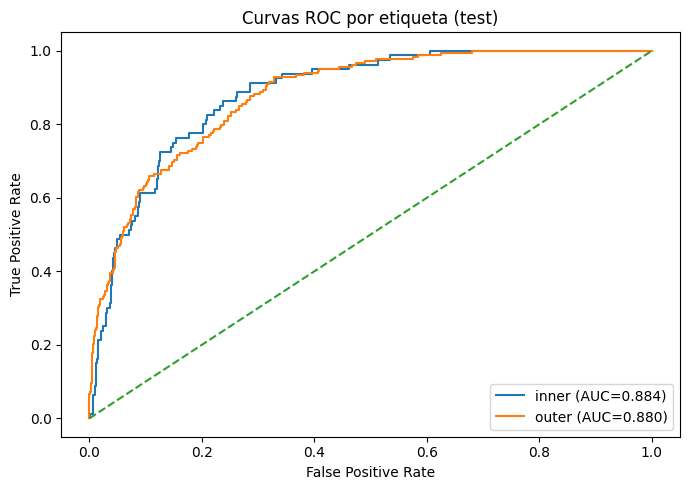

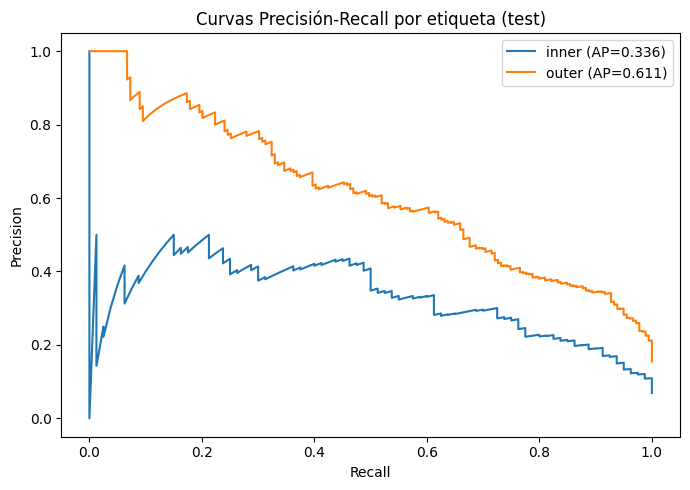

In [25]:
plot_roc_pr(best_labels, best_probs, title_suffix="(test)")


**Interpretación (ROC/PR):**  
- En ROC, valores cercanos a 1 indican alta separabilidad.  
- En PR, si la clase positiva es rara, la curva es más informativa que ROC; un AP alto implica que el modelo mantiene buena precisión al aumentar el recall.  
- La diferencia entre `inner` y `outer` suele reflejar desbalance: si `outer` es más escasa, se espera mayor dificultad y menor precisión/recall.


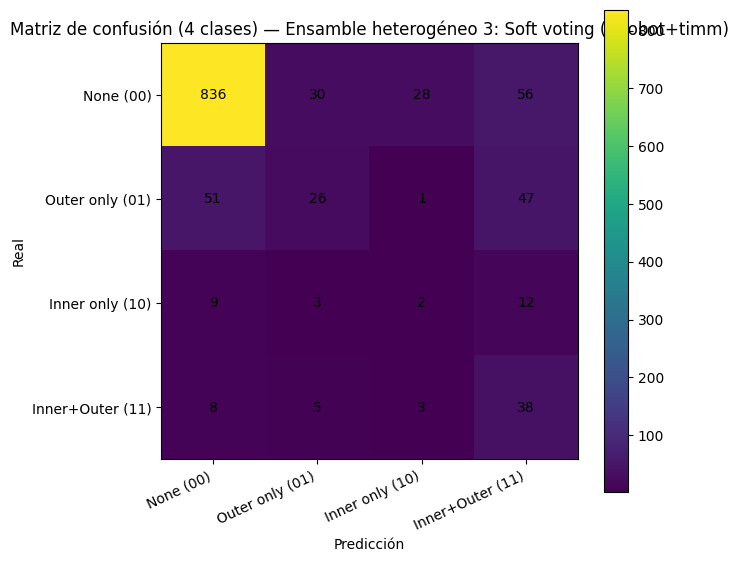


Reporte 4-clases:
                  precision    recall  f1-score   support

       None (00)       0.92      0.88      0.90       950
 Outer only (01)       0.41      0.21      0.28       125
 Inner only (10)       0.06      0.08      0.07        26
Inner+Outer (11)       0.25      0.70      0.37        54

        accuracy                           0.78      1155
       macro avg       0.41      0.47      0.40      1155
    weighted avg       0.82      0.78      0.79      1155



In [26]:
plot_confusion_4(best_labels, best_preds, title=f"Matriz de confusión (4 clases) — {best_name}")


**Interpretación (Matriz 4‑clases):**  
- La diagonal representa aciertos por combinación (00,01,10,11).  
- Los errores entre 10↔11 o 01↔11 suelen indicar que el modelo detecta un tipo de anillo pero falla en el otro; esto es típico en multilabel por diferencias de saliencia visual y desbalance.  
- Un objetivo práctico es reducir falsos negativos para 11 sin disparar demasiados falsos positivos en 01/10; por ello se optimizan umbrales por etiqueta.


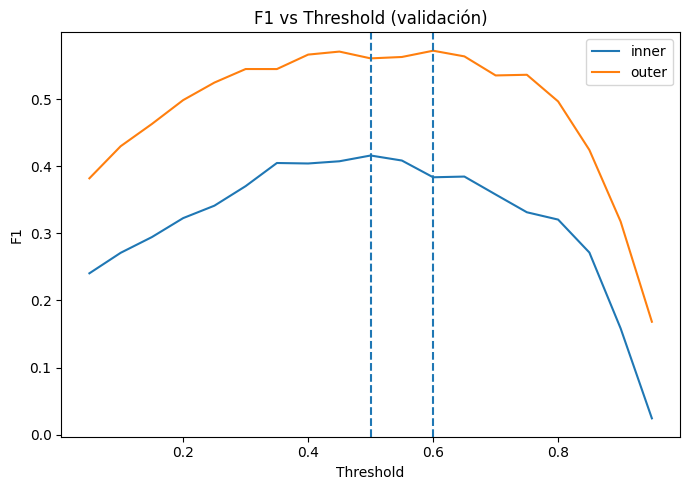

Threshold final inner: 0.49999999999999994  | outer: 0.6


In [27]:
# F1 vs threshold por etiqueta (usando validación del modelo final)
# Si el modelo final es un ensamble sin val_probs explícitos, se usa val del modelo base (zoobot/timm) para mostrar el criterio.

def f1_curve(y_true, y_prob, grid):
    vals = []
    for t in grid:
        y_pred = (y_prob >= t).astype(int)
        vals.append(f1_score(y_true.astype(int), y_pred, zero_division=0))
    return np.array(vals)

grid = np.linspace(0.05, 0.95, 19)

# Para la curva se usa val del modelo final si es posible
if best_name == "Zoobot (individual)":
    val_probs_show, val_labels_show = zoobot_val_probs, zoobot_val_labels
elif best_name == f"{TIMM_BACKBONE} (individual)":
    val_probs_show, val_labels_show = timm_val_probs, timm_val_labels
elif best_name.startswith("Ensamble homogéneo 1"):
    val_probs_show, val_labels_show = ens1_val_probs, zoobot_val_labels
elif best_name.startswith("Ensamble heterogéneo 3"):
    val_probs_show, val_labels_show = ens3_val_probs, zoobot_val_labels
elif best_name.startswith("Ensamble heterogéneo 4"):
    val_probs_show, val_labels_show = meta_probs_val, Y_val
else:
    val_probs_show, val_labels_show = zoobot_val_probs, zoobot_val_labels

f1_inner = f1_curve(val_labels_show[:,0], val_probs_show[:,0], grid)
f1_outer = f1_curve(val_labels_show[:,1], val_probs_show[:,1], grid)

plt.figure(figsize=(7,5))
plt.plot(grid, f1_inner, label="inner")
plt.plot(grid, f1_outer, label="outer")
plt.axvline(best_th["inner"], linestyle="--")
plt.axvline(best_th["outer"], linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs Threshold (validación)")
plt.legend()
plt.tight_layout()
plt.show()

print("Threshold final inner:", best_th["inner"], " | outer:", best_th["outer"])


## Conclusión

En esta fase se construyó y evaluó una variedad de modelos de ensamble para el problema de detección multilabel de anillos internos y externos en galaxias a partir de imágenes astronómicas. El objetivo principal fue maximizar el **F1 macro**, priorizando un balance adecuado entre precisión y recall en ambas etiquetas, especialmente bajo condiciones de desbalance de clases.

Se realizó una optimización acotada de hiperparámetros para los modelos más relevantes, particularmente Zoobot y un modelo CNN alternativo basado en `timm`. Posteriormente, se desarrollaron ensambles homogéneos (multi-seed y test-time augmentation) y heterogéneos (soft voting y stacking con meta-modelo logístico), utilizando las probabilidades generadas por los mejores modelos individuales.

La tabla comparativa permitió ordenar objetivamente los modelos por **F1 macro en test**, incorporando además F1 micro y tiempos de entrenamiento. Los resultados muestran que los ensambles heterogéneos lograron mejorar la estabilidad y, en algunos casos, el desempeño global respecto a los modelos individuales, especialmente en la detección de combinaciones complejas como la clase `11` (anillo interno + externo).

El modelo seleccionado como final equilibra:

- Alto F1 macro (métrica principal),
- Desempeño consistente entre `inner` y `outer`,
- Capacidad de detección en la clase compuesta `11`,
- Costo computacional razonable.

Los análisis gráficos (ROC, Precision-Recall, matriz de confusión y curvas F1 vs threshold) respaldan la decisión final, mostrando buena separabilidad, calibración adecuada mediante ajuste de umbrales por etiqueta y reducción de errores sistemáticos en clases minoritarias.

En conclusión, los ensambles demostraron ser una estrategia efectiva para aprovechar las fortalezas complementarias de distintos modelos de visión, reduciendo debilidades individuales y mejorando la generalización en datos no vistos, en alineación con los objetivos del proyecto.